In [2]:
import pandas as pd
hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [3]:
import io
import subprocess

# my bucket
bucket = "dsan6000-pm1336"
prefix = "wikipedia-hourly/"

listing = subprocess.check_output(
    ["aws", "s3", "ls", f"s3://{bucket}/{prefix}", "--recursive"],
    text=True
)
# all parquet
keys = [
    line.split()[-1]
    for line in listing.splitlines()
    if line.endswith(".parquet")
]

hourly_dfs = []
# hourly data
for hour, key in enumerate(sorted(keys)):
    parquet_data = subprocess.check_output(
        ["aws", "s3", "cp", f"s3://{bucket}/{key}", "-"]
    )

    df = pd.read_parquet(io.BytesIO(parquet_data))
    df["hour"] = hour
    hourly_dfs.append(df)

combined_df = pd.concat(hourly_dfs, ignore_index=True)

len(combined_df), len(hourly_dfs) # combine check


(119708, 24)

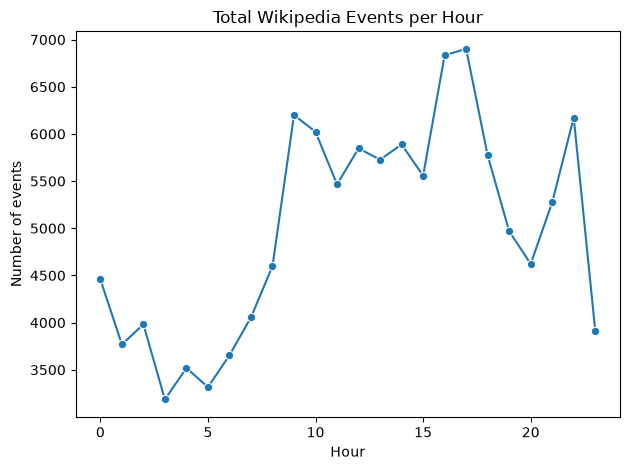

In [4]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

hourly_events = (
    combined_df
    .groupby("hour")
    .size()
    .reset_index(name="events")
)

sns.lineplot(
    data=hourly_events,
    x="hour",
    y="events",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Number of events")
plt.title("Total Wikipedia Events per Hour")
plt.tight_layout()

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")
plt.show()


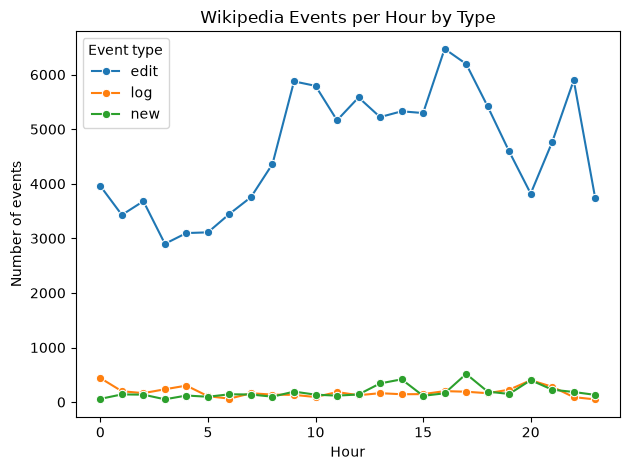

In [7]:
events_by_type = (
    combined_df
    .groupby(["hour", "type"])
    .size()
    .reset_index(name="events")
)

sns.lineplot(
    data=events_by_type,
    x="hour",
    y="events",
    hue="type",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Number of events")
plt.title("Wikipedia Events per Hour by Type")
plt.legend(title="Event type")
plt.tight_layout()

plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")
plt.show()
